# Análise de Infrações PF x PJ


In [1]:
import pandas as pd # Importar dados
import numpy as np # Importar Matemática
import matplotlib.pyplot as plt # Importar gráficos

dados = pd.read_csv('https://raw.githubusercontent.com/JpfMaffei/Analise_de_dados_PFxPJ/refs/heads/main/2.4-infracoes-por-pessoa-24.csv', sep=';') # Carregar o arquivo dos dados a serem analisados
dados = dados.dropna(axis=1, how='all') # Remover colunas vazias
print(dados.head()) # Visualizar as primeiras linhas


   ANOMES                                 DESC_INF     DESCR_MUNIC_INF  \
0  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC  ARMACAO DOS BUZIOS   
1  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC  ARMACAO DOS BUZIOS   
2  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC       IGUABA GRANDE   
3  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC       IGUABA GRANDE   
4  202401  DIRIGIR VEICULO SEM POSSUIR CNH/PPD/ACC              MACUCO   

      LIT_PTO      TIPO    PF   PJ  AIT  
0  GRAVISSIMA    MANUAL   5.0  NaN    5  
1  GRAVISSIMA  PALM TOP  45.0  1.0   46  
2  GRAVISSIMA    MANUAL   7.0  NaN    7  
3  GRAVISSIMA  PALM TOP  19.0  NaN   19  
4  GRAVISSIMA    MANUAL   1.0  NaN    1  


In [2]:
total_pf = dados['PF'].sum() # Somar as infrações de Pessoa Física
total_pj = dados['PJ'].sum() # Somar as infraçoes de Pessoa Jurídica
print(f'Total de infrações pessoa Física: {total_pf} // Total de infrações Pessoa Jurídica: {total_pj}') # Exibir resuldados


Total de infrações pessoa Física: 5398223.0 // Total de infrações Pessoa Jurídica: 1214705.0


In [3]:
# Tabela mostrando as cidades do RJ com mais infrações de PF e PJ em ordem crescente.
dados.groupby('DESCR_MUNIC_INF')[['PF','PJ']].sum().sort_values('PF', ascending = False).head()

,PF,PJ
DESCR_MUNIC_INF,,
RIO DE JANEIRO,2140247.0,634846.0
ITAGUAI,534389.0,65917.0
NITEROI,227866.0,68564.0
MACAE,168099.0,32420.0
CABO FRIO,156604.0,26087.0


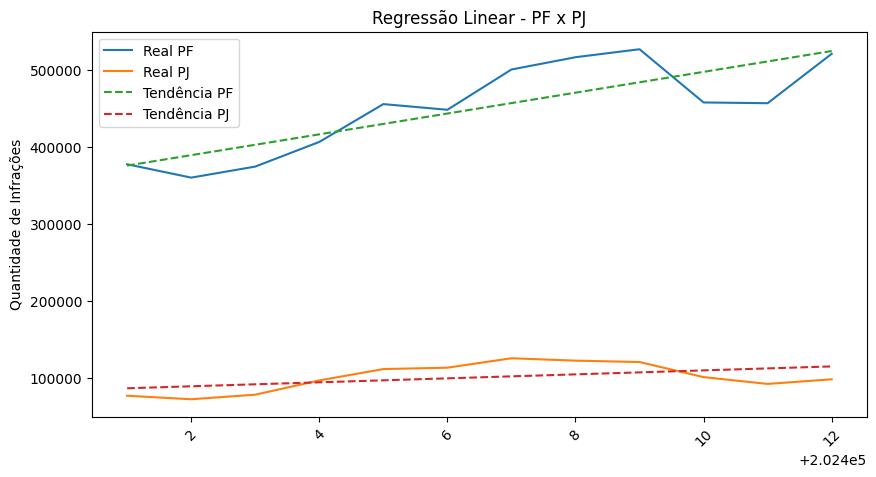

In [4]:
from sklearn.linear_model import LinearRegression # Importar ferramenta de regressão linear
import matplotlib.pyplot as grafico # Importar pyplot da biblioteca matplotlib

# agrupar dados no tempo
tempo = dados.groupby('ANOMES')[['PF','PJ']].sum()

# resetar índice
tempo = tempo.reset_index()

# criar variável numérica (tempo)
tempo['ANOMES_NUM'] = range(len(tempo))

# ======================
# Regressão PF
# ======================
X = tempo[['ANOMES_NUM']]
y_pf = tempo['PF']

modelo_pf = LinearRegression()
modelo_pf.fit(X, y_pf)

tempo['Tendencia_PF'] = modelo_pf.predict(X)

# ======================

# ======================
# Regressão PJ
# ======================
y_pj = tempo['PJ']

modelo_pj = LinearRegression()
modelo_pj.fit(X, y_pj)

tempo['Tendencia_PJ'] = modelo_pj.predict(X)

# ======================

# ======================
# Gráfico completo
# ======================

grafico.figure(figsize=(10,5))

# dados reais
grafico.plot(tempo['ANOMES'], tempo['PF'], label='Real PF')
grafico.plot(tempo['ANOMES'], tempo['PJ'], label='Real PJ')

# tendências (tracejadas)
grafico.plot(tempo['ANOMES'], tempo['Tendencia_PF'], linestyle='--', label='Tendência PF')
grafico.plot(tempo['ANOMES'], tempo['Tendencia_PJ'], linestyle='--', label='Tendência PJ')

grafico.xticks(rotation=45)
grafico.legend()
grafico.title('Regressão Linear - PF x PJ')
grafico.ylabel('Quantidade de Infrações')
grafico.show()

# ======================

In [5]:
infracoes = dados.groupby('DESC_INF')[['PF', 'PJ']].sum()

top_infracoes = infracoes.sort_values('PF', ascending = False).head(10)

top_infracoes

,PF,PJ
DESC_INF,,
TRANSITAR EM VELOCIDADE SUPERIOR A MAXIMA PERMITIDA EM ATE 20%,2253548.0,489943.0
"DEIXAR DE EFETUAR PAGAMENTO, PELO USO DE RODOVIAS E VIAS URBANAS, NA FORMA ESTAB",530912.0,62725.0
TRANSITAR EM VELOCIDADE SUPERIOR A MAXIMA PERMITIDA EM MAIS DE 20% ATE 50%,368165.0,121707.0
"AVANC O SINAL VERM D SEMáF, EXC HOUVER SINALIZ PERM LIVRE CONV à DIRE-FISC ELETR",242052.0,29802.0
TRANSITAR FAIXA/VIA EXCLUSIVA DESTINADA VEIC TRANSP PUBLICO,193330.0,242768.0
"DEIXAR DE EFETUAR REGISTRO DO VEíCULO EM 30 DIAS, QDO FOR TRANSF A PROPRIEDADE",167940.0,23115.0
CONDUZIR O VEICULO REGISTRADO QUE NAO ESTEJA DEVIDAMENTE LICENCIADO,137077.0,4597.0
ESTACIONAR NO PASSEIO,121855.0,15204.0
"CONDUZIR MOTOCICLETA, MOTONETA OU CICLOMOTOR SEM CAPACETE DE SEGURANçA",79720.0,1866.0


/tmp/ipykernel_438/4000794437.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1000x600 with 0 Axes>

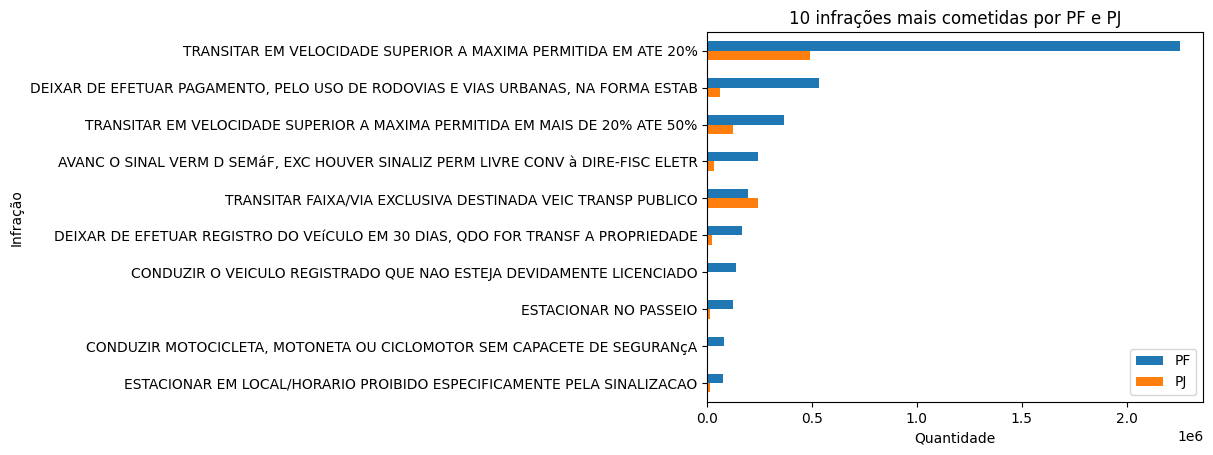

In [10]:
plt.figure(figsize = (10, 6))

top_infracoes.plot(kind = 'barh')

plt.title('10 infrações mais cometidas por PF e PJ')
plt.xlabel('Quantidade')
plt.ylabel('Infração')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()